In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 2, 1, 3, 2, 4], dtype=float)

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
 
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
 
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]                                            # Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i])                              # Main diagonal
        C[i - 1] = h[i]                                                # Superdiagonal
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i]
                       - (y[i] - y[i - 1]) / h[i - 1])                # Right-hand side vector
 
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    b = b.copy()
    d = d.copy()
 
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
 
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
 
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
 
    return x

def evaluate_spline(x_data, y_data, M, x_eval):
    n = len(x_data)
    h = np.diff(x_data)
 
    i = 0
    for j in range(n - 1):
        if x_data[j] <= x_eval <= x_data[j + 1]:
            i = j
            break
 
    dx = x_eval - x_data[i]
 
    a_i = y_data[i]
    b_i = (y_data[i+1] - y_data[i]) / h[i] - h[i] * (2*M[i] + M[i+1]) / 6
    c_i = M[i] / 2
    d_i = (M[i+1] - M[i]) / (6 * h[i])
 
    return a_i + b_i*dx + c_i*dx**2 + d_i*dx**3

In [3]:
A, B, C, D = setup_tridiagonal_matrix(x, y)

M_interior = thomas_algorithm(A, B, C, D)
M = np.zeros(len(x))
M[1:-1] = M_interior

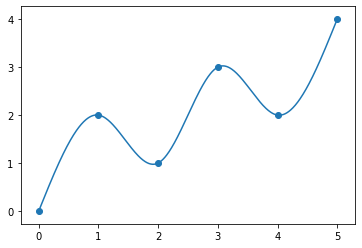

In [5]:
x_fine = np.linspace(x[0], x[-1], 500)
y_fine = np.array([evaluate_spline(x, y, M, xi) for xi in x_fine])
plt.plot(x_fine, y_fine)
plt.scatter(x, y)
plt.show()